In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r"C:\Users\hp\Desktop\heart_disease2.csv")

In [3]:
df["target"].value_counts()

target
1    629
0    561
Name: count, dtype: int64

In [4]:
df["target"].value_counts(normalize=True) * 100

target
1    52.857143
0    47.142857
Name: proportion, dtype: float64

# Heart Disease Prediction using Machine Learning

## Project Objective

The objective of this project is to predict whether a patient is likely to have heart disease based on medical and demographic information.

Machine learning classification algorithms will be used to analyze patient data and identify patterns associated with heart disease.

The performance of different models will be compared using evaluation metrics such as Accuracy, Precision, Recall, and F1-Score.

## Importing Required Libraries

The following libraries are used for data manipulation, visualization, machine learning model building, and model evaluation.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

## Loading the Dataset

The dataset is loaded into a Pandas DataFrame for analysis and preprocessing.

In [3]:
df = pd.read_csv(r"C:\Users\hp\Desktop\heart_disease2.csv")

df.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


## Understanding the Dataset

Before building a machine learning model, it is important to understand the structure of the dataset, including the number of records, features, data types, and missing values.

In [4]:
df.shape

(1190, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   resting bp s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting blood sugar  1190 non-null   int64  
 6   resting ecg          1190 non-null   int64  
 7   max heart rate       1190 non-null   int64  
 8   exercise angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  ST slope             1190 non-null   int64  
 11  target               1190 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 111.7 KB


Observation:

All features are already in numerical format. Therefore, no categorical encoding techniques such as Label Encoding or One-Hot Encoding are required.

In [6]:
df.describe()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
count,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000
mean,53.720168,0.763866,3.232773,132.153782,210.363866,0.213445,0.698319,139.732773,0.387395,0.922773,1.624370,0.528571
std,9.358203,0.424884,0.935480,18.368823,101.420489,0.409912,0.870359,25.517636,0.487360,1.086337,0.610459,0.499393
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,188.000000,0.000000,0.000000,121.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,229.000000,0.000000,0.000000,140.500000,0.000000,0.600000,2.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,269.750000,0.000000,2.000000,160.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop_duplicates()

Observation:

A total of 272 duplicate records were found in the dataset.

Duplicate records were removed to prevent bias and ensure that the machine learning model learns from unique patient observations.

After removing duplicates, the dataset contained 918 rows and 12 columns.

"Why did you remove duplicates?"

Answer:

Duplicate records can give excessive importance to certain observations and may lead to misleading model performance. Therefore, duplicate entries were removed to ensure fair and accurate learning.

In [11]:
df["target"].value_counts()

target
1    508
0    410
Name: count, dtype: int64

In [12]:
df["target"].value_counts(normalize=True) * 100

target
1    55.337691
0    44.662309
Name: proportion, dtype: float64

Observation:

After removing duplicate records, the dataset contained 918 unique patient observations.

The target variable remains relatively balanced, with 508 patients having heart disease and 410 patients without heart disease. Therefore, the dataset is suitable for classification modeling.

# EDA

## Target Variable Distribution

A countplot is used to visualize the number of patients with and without heart disease.

This helps determine whether the dataset is balanced or imbalanced.

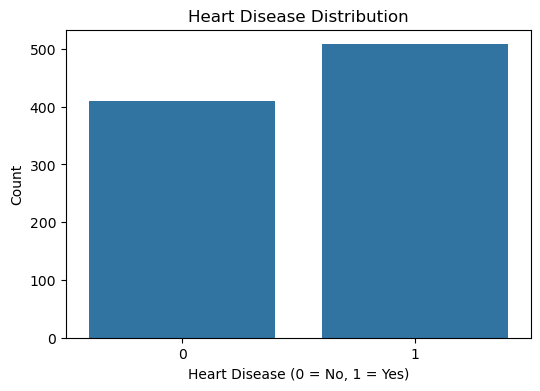

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(x='target', data=df)

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.show()

Observation:

The dataset contains patients both with and without heart disease. The distribution is relatively balanced, making it suitable for classification analysis.

## Age Distribution

A histogram is used to analyze the distribution of patient ages in the dataset.

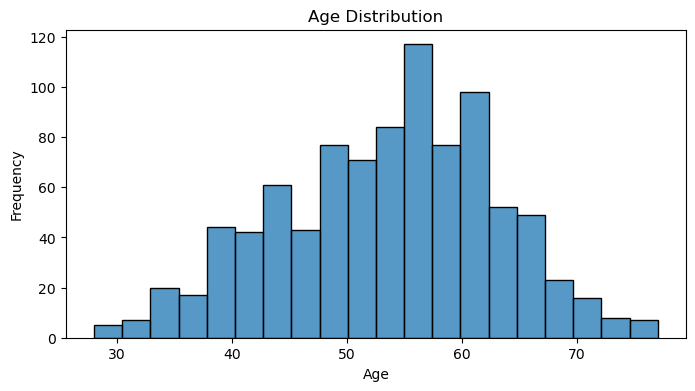

In [14]:
plt.figure(figsize=(8,4))

sns.histplot(df['age'], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

Observation:

The histogram shows the distribution of patient ages. Most patients fall within the middle-age and older-age groups, which are generally associated with a higher risk of heart disease.

## Cholesterol Distribution

This histogram helps analyze the cholesterol levels of patients in the dataset.
Why?

High cholesterol is a major risk factor for cardiovascular diseases.

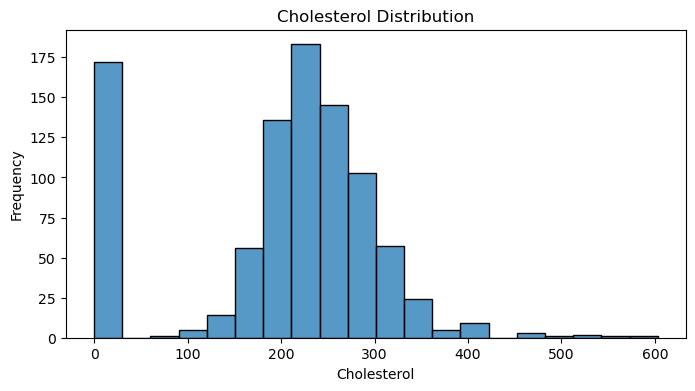

In [15]:
plt.figure(figsize=(8,4))

sns.histplot(df['cholesterol'], bins=20)

plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol")
plt.ylabel("Frequency")

plt.show()

## Gender and Heart Disease

This visualization compares heart disease occurrence across different genders. It helps identify whether gender has any relationship with heart disease risk.

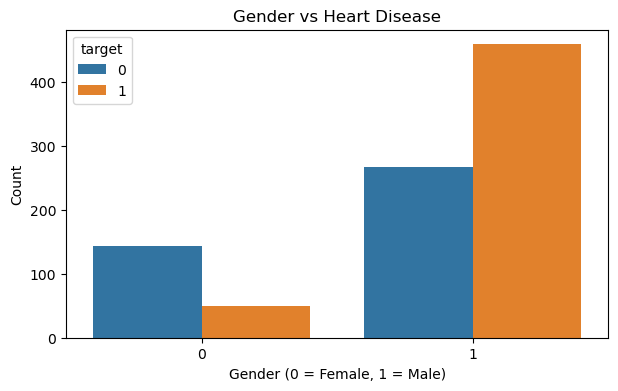

In [16]:
plt.figure(figsize=(7,4))

sns.countplot(x='sex', hue='target', data=df)

plt.title("Gender vs Heart Disease")
plt.xlabel("Gender (0 = Female, 1 = Male)")
plt.ylabel("Count")

plt.show()

Why did we use hue='target'?

The hue parameter helps compare heart disease categories within each gender group, making the relationship easier to visualize.

Code Explanation:

1. plt.figure(figsize=(7,4)) creates a figure with a width of 7 inches and height of 4 inches.

2. sns.countplot() is used to count the number of observations in each category.

3. x='sex' places gender on the x-axis.

4. hue='target' separates each gender category into patients with heart disease and patients without heart disease.

5. data=df specifies that the data should be taken from the DataFrame.

6. plt.title() adds a title to the graph.

7. plt.xlabel() and plt.ylabel() label the axes.

8. plt.show() displays the final visualization.

## Age and Heart Disease

A boxplot is used to compare age distributions between patients with and without heart disease.

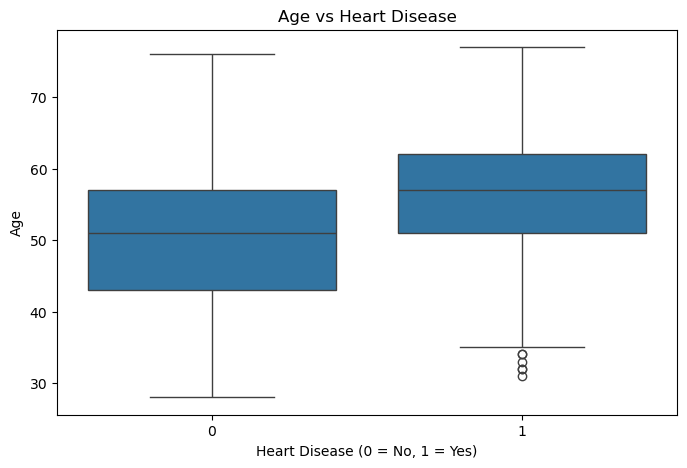

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(x='target', y='age', data=df)

plt.title("Age vs Heart Disease")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Age")

plt.show()

Why use a boxplot instead of a histogram?

A boxplot makes it easier to compare age distributions between multiple groups and also helps identify outliers.

Code Explanation:

1. plt.figure(figsize=(8,5)) creates a figure of size 8×5.

2. sns.boxplot() creates a boxplot to compare age distributions between different heart disease categories.

3. x='target' divides patients into two groups:
   - 0 = No Heart Disease
   - 1 = Heart Disease

4. y='age' places patient age on the vertical axis.

5. The boxplot displays the median, quartiles, spread of data, and potential outliers.

6. plt.title(), plt.xlabel(), and plt.ylabel() improve graph readability.

7. plt.show() displays the boxplot.

## Correlation Analysis

A correlation heatmap is used to measure the relationship between different features in the dataset.

Correlation values range from -1 to +1.

Values closer to +1 indicate a strong positive relationship, while values closer to -1 indicate a strong negative relationship.

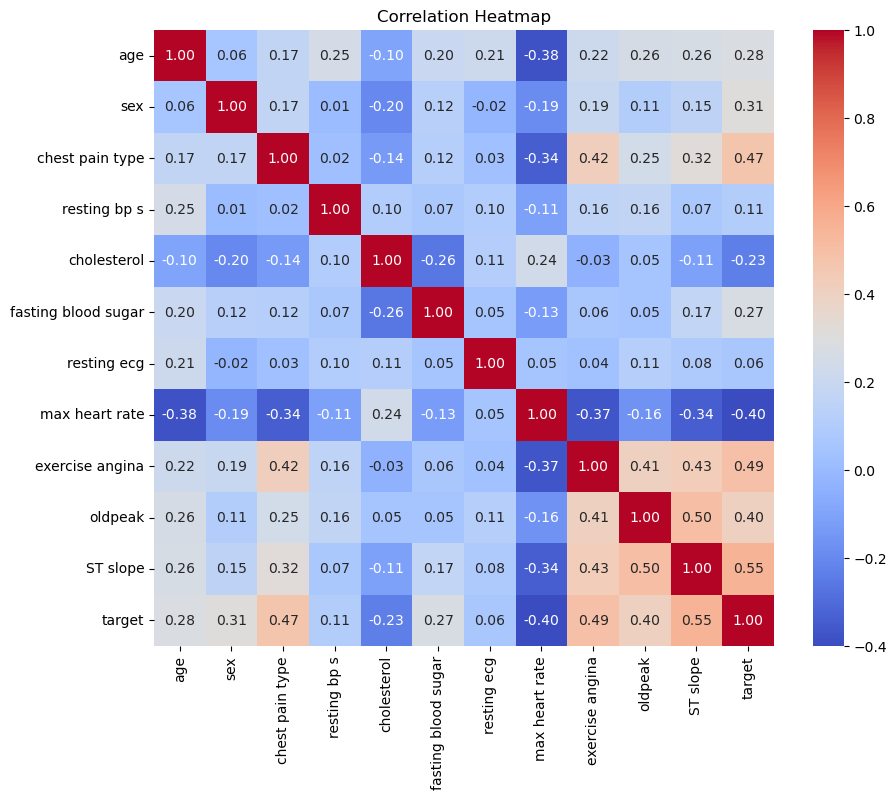

In [18]:
plt.figure(figsize=(10,8))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

Code Explanation:

1. plt.figure(figsize=(10,8)) creates a larger figure to clearly display all feature relationships.

2. df.corr() calculates the correlation coefficient between all numerical features in the dataset.

3. The resulting correlation matrix stores correlation values ranging from -1 to +1.

4. sns.heatmap() visualizes the correlation matrix using colors.

5. annot=True displays correlation values inside each cell.

6. fmt=".2f" limits the displayed values to two decimal places.

7. cmap="coolwarm" applies a color scheme where:
   - Red indicates positive correlation.
   - Blue indicates negative correlation.

8. plt.title() adds a title to the heatmap.

9. plt.show() displays the heatmap.

### Observation:

The correlation heatmap shows that exercise angina, chest pain type, and maximum heart rate have the strongest relationships with heart disease.

Exercise angina (0.49) and chest pain type (0.47) have a moderate positive correlation with the target variable, indicating that they may be important predictors of heart disease.

Maximum heart rate (-0.40) has a moderate negative correlation with the target variable, suggesting that patients with lower maximum heart rates may have a higher likelihood of heart disease.

Features such as resting ECG and resting blood pressure show relatively weak correlations with the target variable.

## Outlier Analysis

Boxplots are used to identify outliers in numerical features such as age, cholesterol, resting blood pressure, and maximum heart rate.

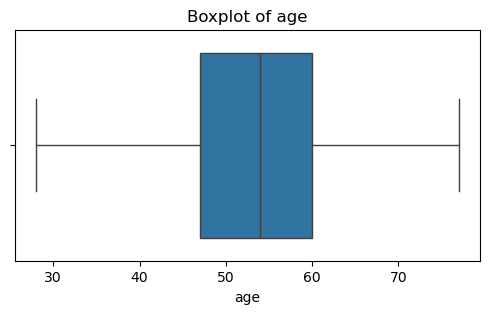

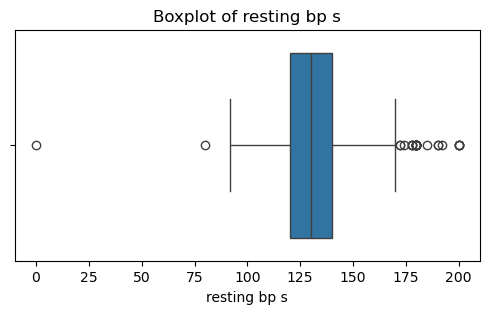

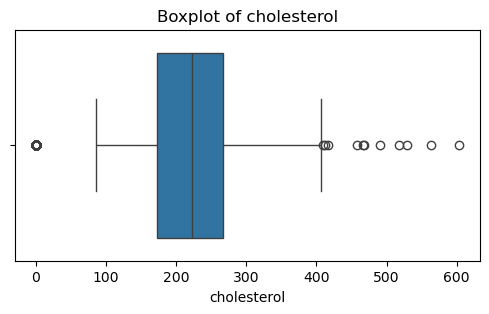

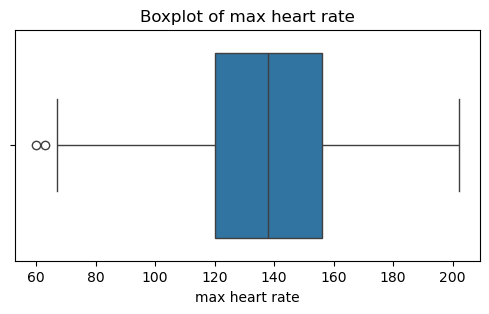

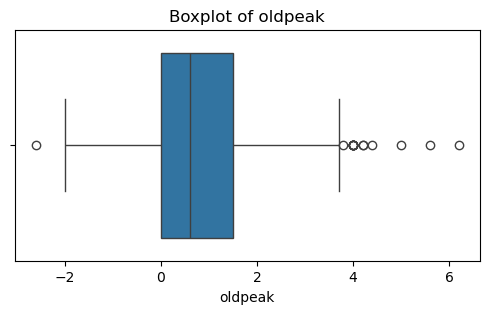

In [19]:
numerical_columns = [
    'age',
    'resting bp s',
    'cholesterol',
    'max heart rate',
    'oldpeak'
]

for column in numerical_columns:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[column])

    plt.title(f"Boxplot of {column}")

    plt.show()

Observation:

The boxplots reveal the presence of outliers in several numerical features.

Cholesterol and Oldpeak contain a significant number of outliers, while Resting Blood Pressure contains a smaller number of outlying observations.

Age and Maximum Heart Rate appear relatively well distributed with fewer extreme values.

Since these values may represent real medical conditions rather than data entry errors, the outliers will be retained for further analysis.

##### Very Important Learning Point ⭐
Should we remove these outliers?

Many beginners immediately remove them.

But in medical datasets, that's not always correct.

Example

Suppose:

Cholesterol = 450

This looks like an outlier.

But medically, some patients genuinely have extremely high cholesterol.

If we remove such patients:

❌ We lose important medical information.

❌ The model may fail to identify high-risk patients.

Viva Question

Why did you keep the outliers?

Answer:

The detected outliers may represent genuine medical conditions rather than errors. Since the dataset is related to healthcare, these extreme values can contain important clinical information. Therefore, they were retained.

## Feature Correlation with Target

A bar chart is used to visualize the correlation of each feature with the target variable.

This helps identify the most influential predictors of heart disease.

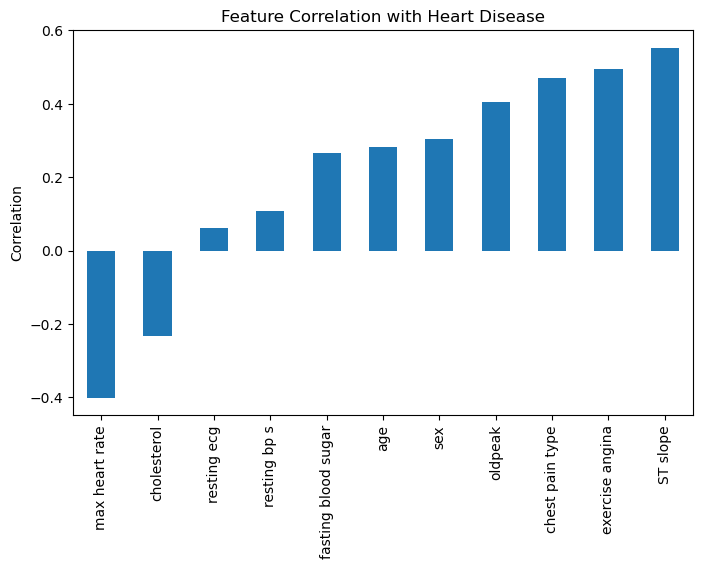

In [21]:
target_corr = df.corr()['target'].drop('target').sort_values()

plt.figure(figsize=(8,5))

target_corr.plot(kind='bar')

plt.title("Feature Correlation with Heart Disease")
plt.ylabel("Correlation")

plt.show()

Code Explanation:

1. df.corr()['target'] calculates the correlation of all features with the target variable.

2. sort_values() arranges the correlations from lowest to highest.

3. plot(kind='bar') creates a bar chart.

4. plt.title() adds a title.

5. plt.ylabel() labels the y-axis.

6. plt.show() displays the chart.

The chart makes it easier to identify which features have the strongest positive or negative relationships with heart disease.

### Observation:

The correlation bar chart shows the relationship between each feature and the target variable (heart disease).

ST Slope (0.55), Exercise Angina (0.49), and Chest Pain Type (0.47) show the strongest positive correlation with heart disease. This indicates that these features may be important predictors for identifying patients at risk.

Oldpeak (0.41), Sex (0.31), Age (0.28), and Fasting Blood Sugar (0.27) also have a positive relationship with the target variable.

Maximum Heart Rate (-0.40) shows the strongest negative correlation with heart disease, suggesting that patients with lower maximum heart rates are more likely to have heart disease.

Cholesterol (-0.23) has a weak negative correlation, while Resting ECG (0.06) and Resting Blood Pressure (0.11) show very weak relationships with the target variable.

Overall, ST Slope, Exercise Angina, Chest Pain Type, Oldpeak, and Maximum Heart Rate appear to be the most influential features in predicting heart disease.

###### What is the difference between the Heatmap and Correlation Bar Chart?

A heatmap shows the correlation between all features in the dataset, whereas a correlation bar chart focuses only on the relationship between each feature and the target variable. The bar chart makes it easier to identify the most important predictors of the target.

# Machine learning phase 

## Defining Features and Target Variable

The dataset is divided into features (X) and target variable (y).

Features contain patient medical information, while the target variable represents the presence or absence of heart disease.

In [22]:
# Features

X = df.drop('target', axis=1)

# Target

y = df['target']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (918, 11)
Target Shape: (918,)


## Train-Test Split

The dataset is divided into training and testing sets.

The training set is used to train the machine learning model, while the testing set is used to evaluate its performance on unseen data.

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape :", X_test.shape)

Training Data Shape: (734, 11)
Testing Data Shape : (184, 11)


Code Explanation:

1. train_test_split() divides the dataset into training and testing sets.

2. X and y are provided as inputs.

3. test_size=0.2 means 20% of the data is reserved for testing and 80% is used for training.

4. random_state=42 ensures reproducible results.

5. X_train and y_train contain training data.

6. X_test and y_test contain testing data.

7. shape is used to verify the number of samples in each set.

## Feature Scaling

Feature scaling is applied to standardize numerical features.

This ensures that all features contribute equally during model training.

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


Code Explanation:

1. StandardScaler() creates a feature scaling object.

2. fit_transform() calculates the mean and standard deviation from the training data and scales the training features.

3. transform() applies the same scaling parameters to the testing data.

4. Scaling is performed only after train-test split to prevent data leakage.

5. The scaled datasets are stored in X_train_scaled and X_test_scaled.

Why do we fit the scaler only on training data?

Answer:

The scaler is fitted only on training data to prevent information from the testing set from influencing the training process. This ensures a fair evaluation of model performance.

In [27]:
X_train.shape

(734, 11)

## Logistic Regression Model

Logistic Regression is a supervised machine learning algorithm used for classification tasks.

The model predicts whether a patient is likely to have heart disease based on medical features.

In [28]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)

lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

Logistic Regression is used to classify patients into heart disease and non-heart disease categories.

The model is trained using the scaled training data and then used to make predictions on the testing data.

In [29]:
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Accuracy : 0.8478260869565217
Precision: 0.9072164948453608
Recall   : 0.822429906542056
F1 Score : 0.8627450980392157


The model is evaluated using Accuracy, Precision, Recall, and F1-Score to measure its classification performance.

Small Learning Point

Notice something interesting:

Accuracy = 84.78%
Precision = 90.72%
What does this mean?

When the model says:

"This patient has heart disease"

it is correct about 91% of the time.

For medical applications, high precision is often valuable because it reduces false alarms

## Decision Tree Classifier

Decision Tree is a classification algorithm that makes predictions by splitting data into smaller groups based on feature values.

It creates a tree-like structure that helps classify patients as having heart disease or not.

In [30]:
from sklearn.tree import DecisionTreeClassifier

# Create model
dt_model = DecisionTreeClassifier(
    random_state=42
)

# Train model
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [31]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)

dt_precision = precision_score(y_test, y_pred_dt)

dt_recall = recall_score(y_test, y_pred_dt)

dt_f1 = f1_score(y_test, y_pred_dt)

print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)

Accuracy : 0.8260869565217391
Precision: 0.8947368421052632
Recall   : 0.794392523364486
F1 Score : 0.8415841584158416


A Decision Tree model was trained to classify patients based on medical features. The model learns decision rules from the training data and uses them to predict heart disease on unseen patients.

In [32]:
print("Tree Depth:", dt_model.get_depth())
print("Number of Leaves:", dt_model.get_n_leaves())

Tree Depth: 16
Number of Leaves: 108


## Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

The final prediction is determined by the majority vote of all trees.

In [33]:
from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [34]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(y_test, y_pred_rf)

rf_recall = recall_score(y_test, y_pred_rf)

rf_f1 = f1_score(y_test, y_pred_rf)

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Accuracy : 0.8804347826086957
Precision: 0.9047619047619048
Recall   : 0.8878504672897196
F1 Score : 0.8962264150943396


Random Forest combines multiple decision trees to make predictions. By aggregating the results of many trees, it generally provides better performance and reduces the risk of overfitting.

### Observation:

Three machine learning models were trained and evaluated for heart disease prediction.

Among all models, Random Forest achieved the highest accuracy of 88.04%, along with strong Precision, Recall, and F1-Score values.

Logistic Regression also performed well, achieving an accuracy of 84.78%.

Decision Tree achieved an accuracy of 82.61%, which was lower than both Logistic Regression and Random Forest.

Based on the evaluation metrics, Random Forest was identified as the best-performing model for this dataset.

## Model Performance Comparison

A bar chart is used to compare the accuracy of different machine learning models.

In [36]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)

dt_accuracy = accuracy_score(y_test, y_pred_dt)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

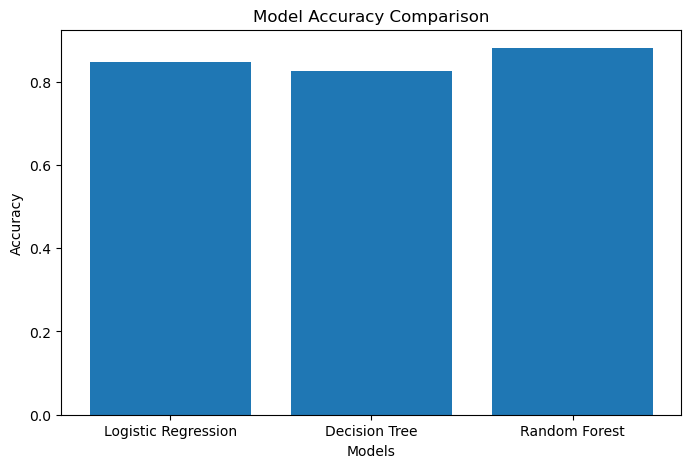

In [37]:
models = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest"
]

accuracies = [
    lr_accuracy,
    dt_accuracy,
    rf_accuracy
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

The bar chart provides a visual comparison of model accuracy and helps identify the best-performing algorithm.

## Feature Importance Analysis

Feature importance helps identify which medical features contribute most to heart disease prediction.

In [38]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
10,ST slope,0.236519
9,oldpeak,0.118054
4,cholesterol,0.110865
8,exercise angina,0.102810
7,max heart rate,0.102528
2,chest pain type,0.095888
0,age,0.086840
3,resting bp s,0.066955
1,sex,0.034592
6,resting ecg,0.025038


Code Explanation:

1. A DataFrame named feature_importance is created using two columns:
   - Feature: Contains the names of all input features.
   - Importance: Contains the importance scores assigned by the Random Forest model.

2. rf_model.feature_importances_ returns the contribution of each feature in making predictions.

3. sort_values() arranges the features in descending order of importance.

4. ascending=False ensures that the most important features appear at the top.

5. The final DataFrame displays the importance ranking of all features.

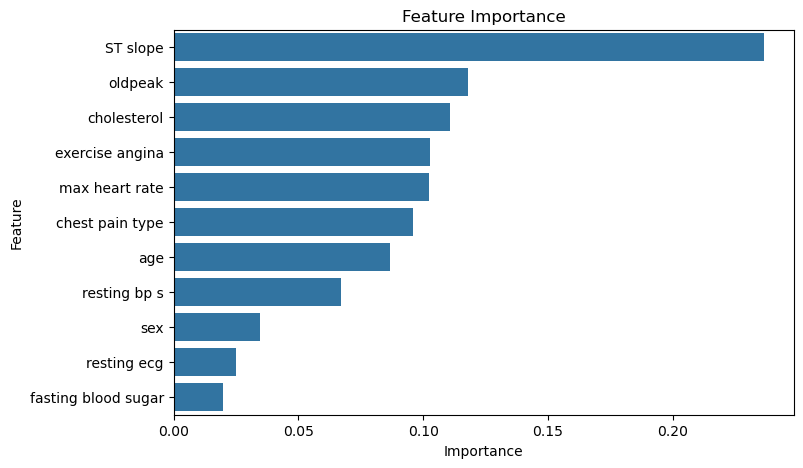

In [39]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")

plt.show()

#### Observation:

The feature importance analysis indicates that ST Slope is the most influential feature in predicting heart disease, with an importance score of 0.2365.

Oldpeak, Cholesterol, Exercise Angina, and Maximum Heart Rate are also among the top contributing features.

Features such as Resting ECG and Fasting Blood Sugar have relatively low importance scores, suggesting that they contribute less to the prediction process.

Overall, the Random Forest model relies heavily on ST Slope, Oldpeak, Cholesterol, Exercise Angina, and Maximum Heart Rate when predicting heart disease.

In [40]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [0.8478, 0.8261, 0.8804],
    'Precision': [0.9072, 0.8947, 0.9048],
    'Recall': [0.8224, 0.7944, 0.8879],
    'F1 Score': [0.8627, 0.8416, 0.8962]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8478,0.9072,0.8224,0.8627
1,Decision Tree,0.8261,0.8947,0.7944,0.8416
2,Random Forest,0.8804,0.9048,0.8879,0.8962


# Conclusion

In this project, a Heart Disease Prediction system was developed using machine learning techniques.

The dataset was first cleaned by removing duplicate records and then analyzed using exploratory data analysis (EDA). Various visualizations such as histograms, boxplots, countplots, and correlation heatmaps were used to understand the data and identify important patterns.

Three machine learning models were trained and evaluated:
- Logistic Regression
- Decision Tree
- Random Forest

Among these models, Random Forest achieved the best performance with an accuracy of 88.04%, precision of 90.48%, recall of 88.79%, and F1-score of 89.62%.

Feature importance analysis revealed that ST Slope, Oldpeak, Cholesterol, Exercise Angina, and Maximum Heart Rate were the most important predictors of heart disease.

Based on the evaluation results, Random Forest was selected as the best model for heart disease prediction.